In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

# Шаг 1: Загрузка данных
data = pd.read_csv("../data/lb3/Mall_Customers.csv")

# Предварительный просмотр данных
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


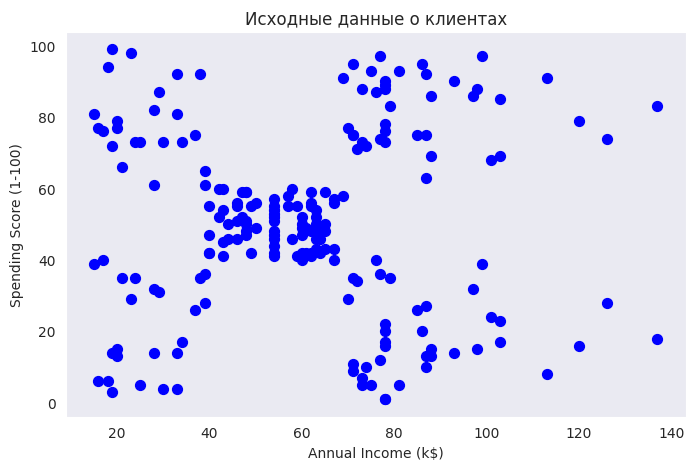

In [2]:

# Шаг 2: Предварительная обработка данных
# Преобразуем пол из категориальных переменных в числовые
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

# Выбираем только нужные столбцы для кластеризации
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Шаг 3: Визуализация исходных данных
plt.figure(figsize=(8,5))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c='blue', s=50)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Исходные данные о клиентах')
plt.grid()
plt.show()

In [ ]:
# На графике представлены данные о клиентах торгового центра, где по оси X указан годовой доход (тыс. долларов), а по оси Y — оценка трат (баллы от 1 до 100). Точки отображают распределение клиентов в пространстве признаков. Мы видим, что клиенты распределены неравномерно, формируя несколько плотных скоплений. Это указывает на наличие групп клиентов с разными паттернами потребления. Например, можно заметить группы с высоким доходом и высокой оценкой трат, а также группы с низким доходом и низкой оценкой трат. Эти закономерности мотивируют нас использовать алгоритмы кластеризации для более точного выявления групп.

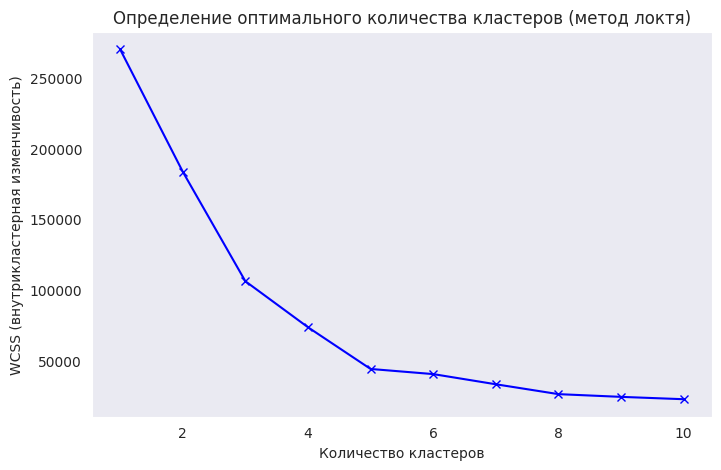

In [3]:
# График показывает зависимость значения WCSS (внутрикластерной изменчивости) от количества кластеров. Видно, что при увеличении числа кластеров значение WCSS значительно уменьшается на начальных этапах, но после точки излома (примерно на значении K = 5) улучшение становится незначительным. Это указывает на то, что оптимальное количество кластеров в данном случае — пять. Использование метода локтя позволяет избежать как чрезмерной детализации (слишком много кластеров), так и излишнего обобщения (слишком мало кластеров).




# Шаг 4: Определение оптимального количества кластеров (метод локтя)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, 'bx-')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS (внутрикластерная изменчивость)')
plt.title('Определение оптимального количества кластеров (метод локтя)')
plt.grid()
plt.show()

In [ ]:
# На итоговом графике показаны кластеры, выделенные методом K-Means. Разные цвета обозначают различные кластеры, а жёлтые звёздочки указывают на центроиды. Мы видим пять четко выделенных кластеров:
#
# Кластер с высоким доходом и высокой оценкой трат.
#
# Кластер с низким доходом и низкой оценкой трат.
#
# Группа с средним доходом и разным уровнем трат.
#
# Группа с низким доходом и высокой оценкой трат.
#
# Группа с высоким доходом и низкой оценкой трат.
#
# Такая сегментация позволяет лучше понять потребительское поведение и помогает в маркетинговых стратегиях. Например, можно выделить целевые группы для акций и предложений: клиенты с высоким доходом и высокой оценкой трат могут быть заинтересованы в эксклюзивных предложениях, а клиенты с низким доходом и высокой оценкой трат — в скидках и акциях.

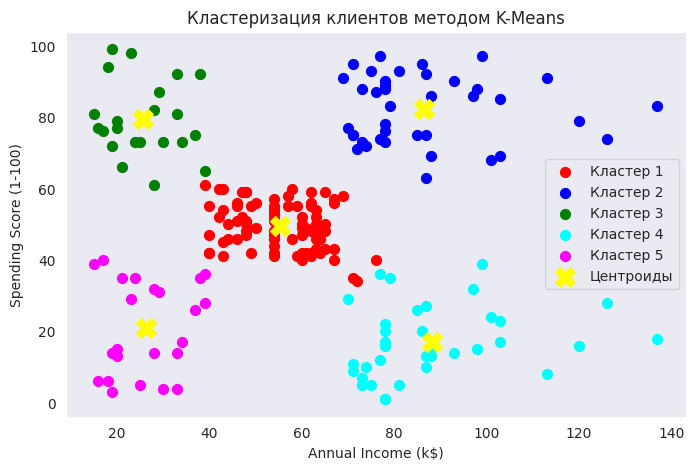

In [4]:



# Оптимальное количество кластеров — обычно выбирается визуально (например, 5)
n_clusters = 5

# Шаг 5: Выполнение кластеризации методом K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# Добавим полученные кластеры в исходные данные для наглядности
X = X.copy()
X['Cluster'] = labels

# Шаг 6: Визуализация результатов кластеризации
plt.figure(figsize=(8,5))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(n_clusters):
    plt.scatter(X[X['Cluster'] == i].iloc[:,0],
                X[X['Cluster'] == i].iloc[:,1],
                s=50, c=colors[i], label=f'Кластер {i+1}')

# Визуализация центроидов
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', marker='X', label='Центроиды')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Кластеризация клиентов методом K-Means')
plt.legend()
plt.grid()
plt.show()

In [ ]:

# Шаг 7: Оценка качества кластеризации
silhouette_avg = silhouette_score(X.iloc[:, :2], labels)
print(f'Средний силуэтный коэффициент для {n_clusters} кластеров: {silhouette_avg:.3f}')

In [5]:
# Средний силуэтный коэффициент
# Средний силуэтный коэффициент для 5 кластеров составил 0.554. Это значение находится в диапазоне от 0 до 1 и указывает на умеренное качество кластеризации:
#
# Значения ближе к 1 указывают на хорошо разделенные кластеры.
#
# Значения ближе к 0 означают перекрытие кластеров.
#
# Отрицательные значения означают неправильное распределение.
#
# Значение 0.554 говорит о том, что кластеры имеют относительно хорошее разделение, но присутствуют некоторые точки, которые могли бы принадлежать другому кластеру. Это типично для реальных данных, особенно когда кластеры частично перекрываются или имеют сложные формы. Улучшить силуэтный коэффициент можно за счет выбора другого алгоритма кластеризации (например, GMM или DBSCAN) или предварительного уменьшения размерности данных.

Средний силуэтный коэффициент для 5 кластеров: 0.554
